AI OBJECT DETECTION SYSTEM (YOLOv8)

📤 Upload Image:


Saving ChatGPT Image Apr 2, 2026, 12_11_30 PM.png to ChatGPT Image Apr 2, 2026, 12_11_30 PM.png


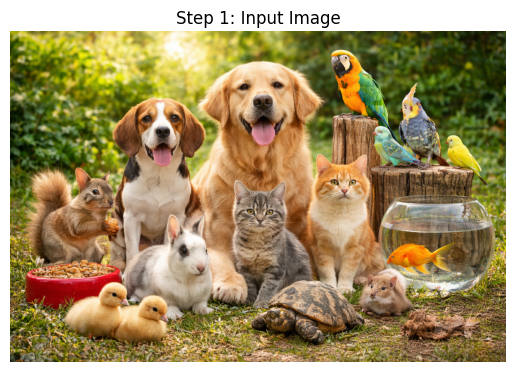


🔄 Loading YOLO model...
✅ Model loaded

🚀 Running detection...

0: 448x640 6 birds, 4 cats, 3 dogs, 1 bowl, 1 potted plant, 167.5ms
Speed: 1.6ms preprocess, 167.5ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


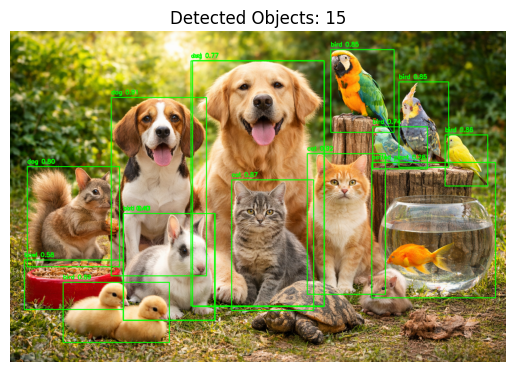


📊 FINAL RESULT:
Total Objects Detected: 15
CAT : 4
DOG : 3
BIRD : 6
BOWL : 1
POTTED PLANT : 1


In [6]:
# Install (only first time)
!pip install ultralytics opencv-python matplotlib

import cv2 as c
import matplotlib.pyplot as p
import numpy as n
from ultralytics import YOLO

print("="*50)
print("AI OBJECT DETECTION SYSTEM (YOLOv8)")
print("="*50)

# ---------------- STEP 1: INPUT ----------------
try:
    from google.colab import files as f
    print("\n📤 Upload Image:")
    up = f.upload()
    path = list(up.keys())[0]
except:
    path = input("Enter image path: ")

img = c.imread(path)

if img is None:
    print("❌ Image not found. Using demo...")
    img = n.ones((500, 700, 3), dtype=n.uint8) * 200
    c.rectangle(img, (50, 100), (200, 300), (0, 0, 255), -1)
    c.circle(img, (400, 200), 80, (255, 0, 0), -1)

# ---------------- STEP 2: SHOW INPUT ----------------
p.imshow(c.cvtColor(img, c.COLOR_BGR2RGB))
p.title("Step 1: Input Image")
p.axis('off')
p.show()

# ---------------- STEP 3: LOAD MODEL ----------------
print("\n🔄 Loading YOLO model...")
model = YOLO("yolov8s.pt")   # better than nano
print("✅ Model loaded")

# ---------------- STEP 4: DETECTION ----------------
print("\n🚀 Running detection...")
results = model(img, conf=0.25)   # lower threshold → more detection

# ---------------- STEP 5: PROCESS ----------------
out = img.copy()
labels = []

for r in results:
    for b in r.boxes:
        x1, y1, x2, y2 = map(int, b.xyxy[0])
        conf = float(b.conf[0])
        cls = int(b.cls[0])
        name = model.names[cls]

        labels.append(name)

        # Draw box
        c.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Label with confidence
        txt = f"{name} {conf:.2f}"
        c.putText(out, txt, (x1, y1-10),
                  c.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# ---------------- STEP 6: COUNT ----------------
count_map = {}
for l in labels:
    count_map[l] = count_map.get(l, 0) + 1

# ---------------- STEP 7: OUTPUT IMAGE ----------------
p.imshow(c.cvtColor(out, c.COLOR_BGR2RGB))
p.title(f"Detected Objects: {len(labels)}")
p.axis('off')
p.show()

# ---------------- STEP 8: FINAL RESULT ----------------
print("\n📊 FINAL RESULT:")
print("Total Objects Detected:", len(labels))

for k, v in count_map.items():
    print(f"{k.upper()} : {v}")